In [ ]:
# Import required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# 1. Generate Training Data

np.random.seed(42)
num_samples = 5000
latent_dim = 5

# Generate latent noise samples
Z = np.random.normal(0, 1, (num_samples, latent_dim))

# Define target output
Y = np.zeros((num_samples, 2))
Y[:, 0] = np.sin(Z[:, 0])
Y[:, 1] = np.cos(Z[:, 1])


In [ ]:
# 2. Build the Generative Multi-Layer Network Model

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(latent_dim,)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(2))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Train the Model
history = model.fit(Z, Y,epochs=100,batch_size=32,verbose=1)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0888
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0142
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0087
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0054
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0026
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.9927e-04
Epoch 12/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.6661e-04
Epoch 13/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.5106e-04
Epoch 14/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5481e-04
Epoch 15/100
157/157 ━━━━━━

In [ ]:
# 4. Generate New Samples Using the Trained Model
Z_new = np.random.normal(0, 1, (1000, latent_dim))
generated_outputs = model.predict(Z_new)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


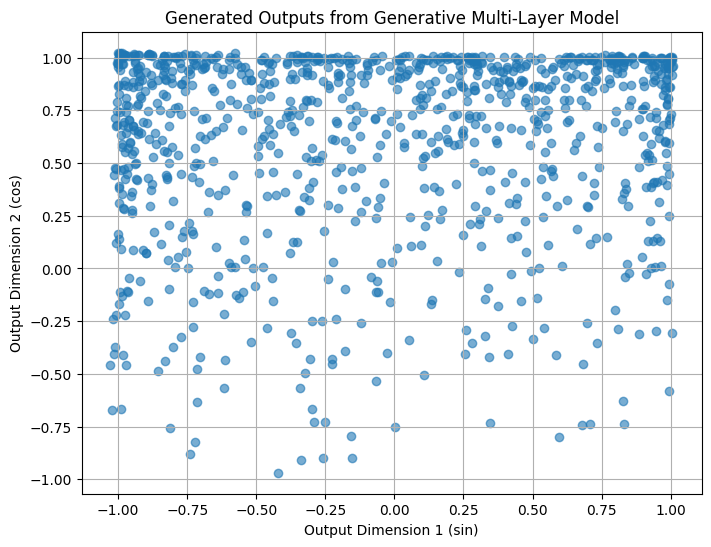

In [ ]:
# 5. Visualize the Generated Outputs
plt.figure(figsize=(8, 6))
plt.scatter(generated_outputs[:, 0],generated_outputs[:, 1],alpha=0.6)
plt.title("Generated Outputs from Generative Multi-Layer Model")
plt.xlabel("Output Dimension 1 (sin)")
plt.ylabel("Output Dimension 2 (cos)")
plt.grid()
plt.show()